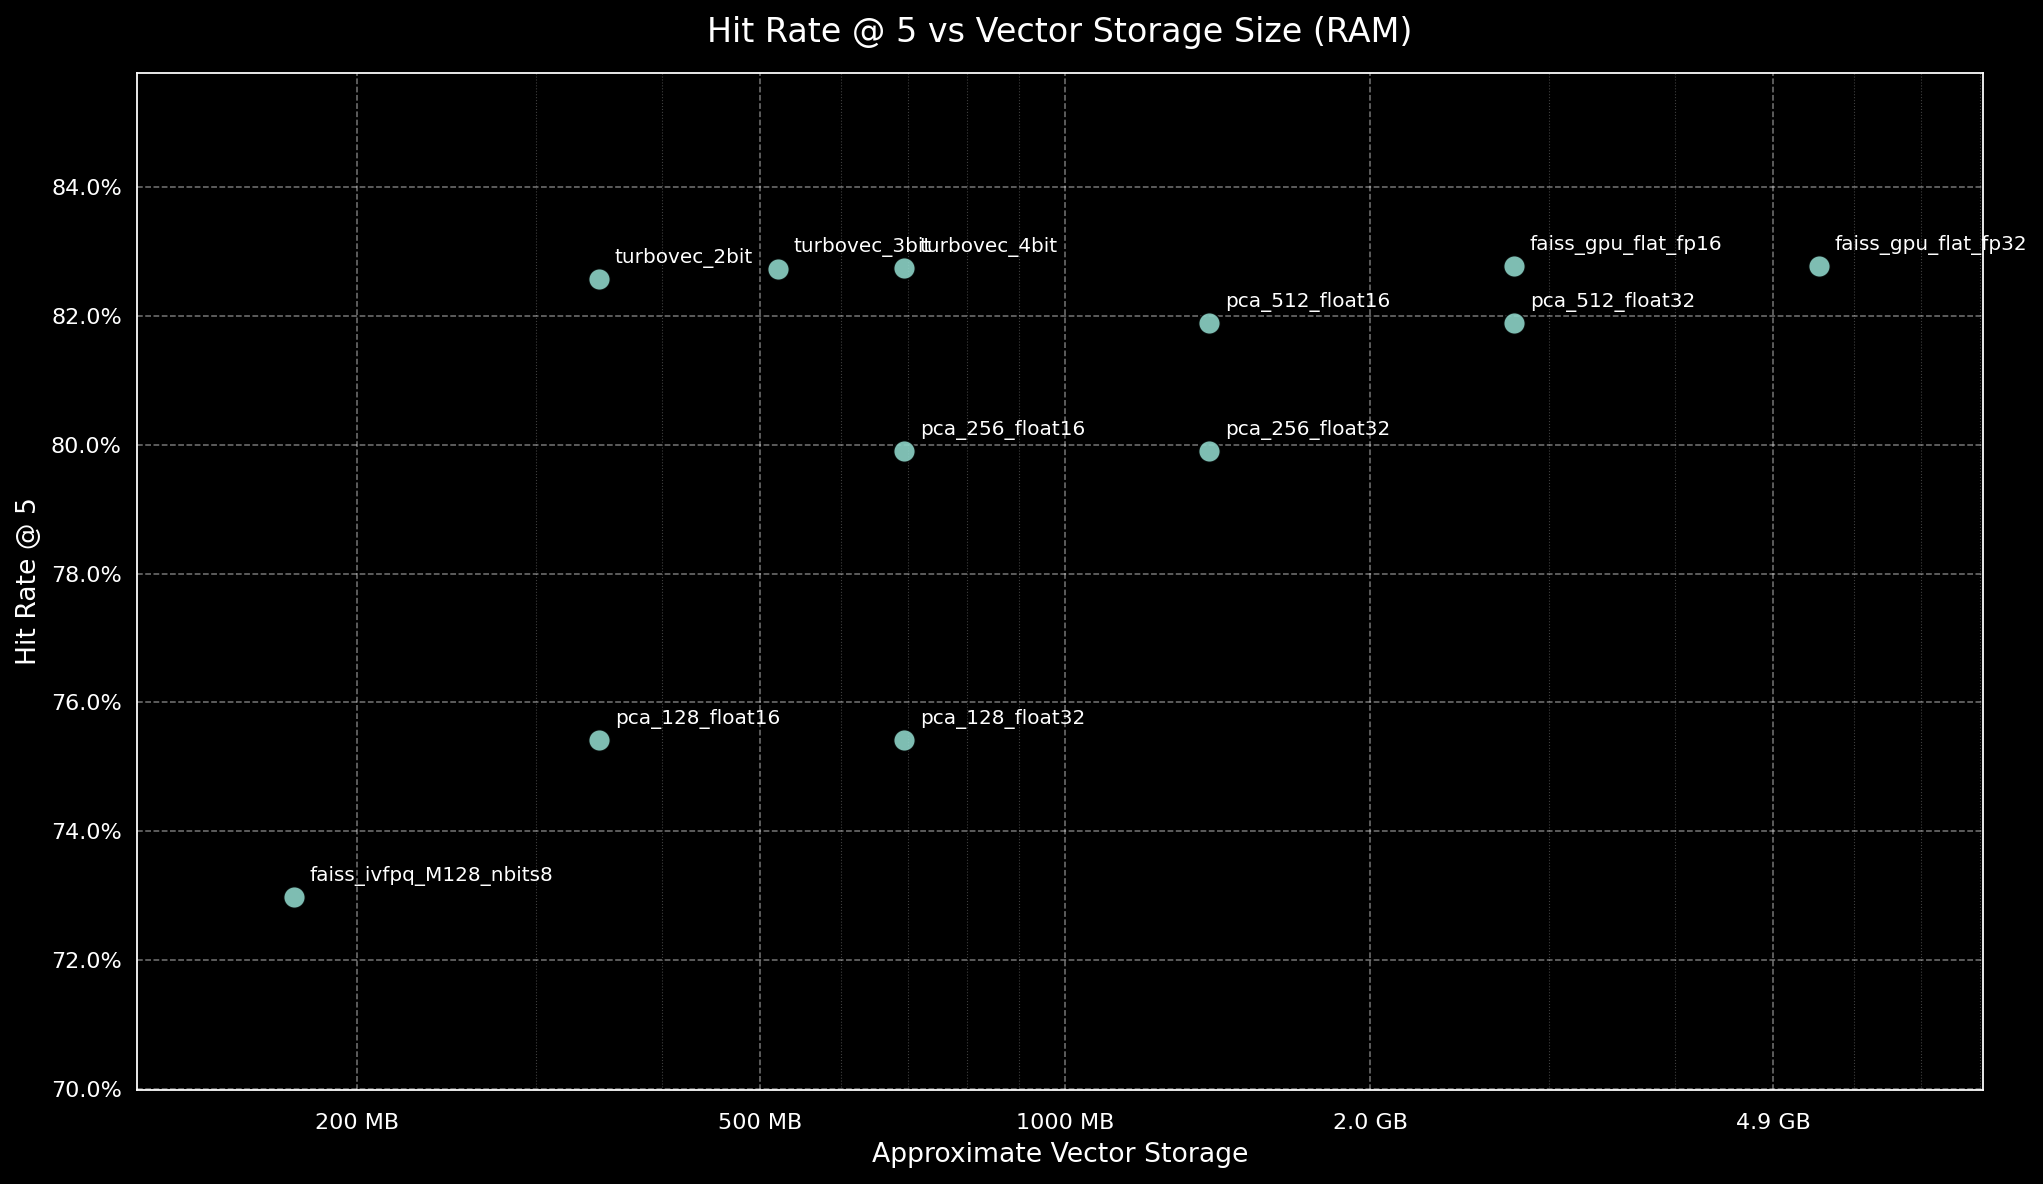

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import PercentFormatter

csv_path = "data/updated_compression_results.csv"
df = pd.read_csv(csv_path)

plot_df = df[["index", "approx_vector_storage_mb", "hit_rate@5"]].copy()

plot_df["approx_vector_storage_mb"] = pd.to_numeric(
    plot_df["approx_vector_storage_mb"],
    errors="coerce"
)

plot_df["hit_rate@5"] = pd.to_numeric(
    plot_df["hit_rate@5"],
    errors="coerce"
)

plot_df = plot_df.dropna(
    subset=["index", "approx_vector_storage_mb", "hit_rate@5"]
)

plot_df = plot_df.sort_values(
    "approx_vector_storage_mb",
    ascending=False
).reset_index(drop=True)


def format_mb_tick(x, pos):
    if x >= 1024:
        return f"{x / 1024:.1f} GB"
    elif x >= 1:
        return f"{x:g} MB"
    else:
        return f"{x * 1024:g} KB"


fig, ax = plt.subplots(figsize=(13, 7.5), dpi=160)

ax.scatter(
    plot_df["approx_vector_storage_mb"],
    plot_df["hit_rate@5"],
    s=95,
    edgecolors="black",
    linewidths=0.7,
    alpha=0.9,
)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["index"],
        xy=(row["approx_vector_storage_mb"], row["hit_rate@5"]),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=9,
        ha="left",
        va="bottom",
    )

# Better x-axis markers
ax.set_xscale("log")

ax.xaxis.set_major_locator(
    ticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0), numticks=20)
)

ax.xaxis.set_minor_locator(
    ticker.LogLocator(base=10, subs=(3.0, 4.0, 6.0, 7.0, 8.0, 9.0), numticks=50)
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(format_mb_tick)
)

ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.tick_params(axis="x", which="major", length=7, width=1.1, labelsize=10)
ax.tick_params(axis="x", which="minor", length=4, width=0.8)

ax.set_xlabel("Approximate Vector Storage", fontsize=12)
ax.set_ylabel("Hit Rate @ 5", fontsize=12)
ax.set_title("Hit Rate @ 5 vs Vector Storage Size (RAM)", fontsize=15, pad=14)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)

x_min = plot_df["approx_vector_storage_mb"].min()
x_max = plot_df["approx_vector_storage_mb"].max()
y_min = plot_df["hit_rate@5"].min()
y_max = plot_df["hit_rate@5"].max()

ax.set_xlim(x_min * 0.70, x_max * 1.45)
ax.set_ylim(max(0, y_min - 0.03), min(1, y_max + 0.03))

plt.tight_layout()

plt.savefig("data/hit_rate_at_5_vs_vector_storage.png", dpi=300, bbox_inches="tight")
plt.savefig("data/hit_rate_at_5_vs_vector_storage.pdf", bbox_inches="tight")

plt.show()